In [1]:
import pandas as pd
job_vision = pd.read_csv(
    r"F:\sanazi\python\data science\code\JobVision_Jobposts_Dataset\JobVision_Jobposts_Dataset.csv"
)
job_vision

,RowNumber,Jobpost_RawTitle,Jobpost_PreferredGender,Jobpost_ProvinceFa,Jobpost_ProvinceEn,Jobpost_WorkTypeFa,Jobpost_WorkTypeEn,Jobpost_SalaryCanBeShown,Jobpost_MinSalary,Jobpost_MaxSalary,...,Company_CityFa,Company_CityEn,Comany_CompanyOwnershipTypesFa,Company_CompanyOwnershipTypesEn,Company_SizeFa,Company_SizeEn,Company_ActivityTypeFa,Company_ActivityTypeEn,Company_IndustryFa,Company_IndustryEn
0,1,مهندس مکانیک,تفاوتی ندارد,تهران,Tehran,پاره وقت,Part Time,False,NaN,NaN,...,تهران,Tehran,خصوصی,Privately held,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی,Iranian company dealing only with Iranian enti...,"ساختمان / مصالح و تجهیزات ساختمانی,تولیدی / صنعتی","Construction / Building Materials & Equipment,..."
1,2,طراح و گرافیست,تفاوتی ندارد,تهران,Tehran,تمام وقت,Full Time,False,NaN,NaN,...,تهران,Tehran,خصوصی,Privately held,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and forei...,طراحی / گرافیک / هنر,Design / Arts
2,3,برنامه نویس full-stack,تفاوتی ندارد,خراسان رضوی,Khorasan Razavi,تمام وقت,Full Time,False,NaN,NaN,...,مشهد,Mashhad,خصوصی,Privately held,زیر 10 نفر,Less than 10 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and forei...,"اینترنت / تجارت الکترونیک / خدمات آنلاین,شرکت ...",Internet Provider / E-commerce / Online Servic...
3,4,بازاریاب - خانم,فقط خانم,البرز,Alborz,تمام وقت,Full Time,False,NaN,NaN,...,کرج,Karaj,خصوصی,Privately held,زیر 10 نفر,Less than 10 employees,شرکت ایرانی دارای مشتریان داخلی,Iranian company dealing only with Iranian enti...,"اینترنت / تجارت الکترونیک / خدمات آنلاین,خرده ...",Internet Provider / E-commerce / Online Servic...
4,5,برنامه نویس React Native,تفاوتی ندارد,اصفهان,Isfahan,پاره وقت,Part Time,False,NaN,NaN,...,اصفهان,Isfahan,خصوصی,Privately held,501 تا 1000 نفر,501 - 1000 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and forei...,فناوری اطلاعات / نرم افزار و سخت افزار,IT / Software / Hardware
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364833,364834,کارشناس حسابداری,تفاوتی ندارد,تهران,Tehran,تمام وقت,Full Time,False,NaN,NaN,...,تهران,Tehran,خصوصی,Privately held,201 تا 500 نفر,201 - 500 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and forei...,تجارت / بازرگانی,Trading / International Affairs
364834,364835,حسابدار ارشد,ترجیحاً خانم,البرز,Alborz,تمام وقت,Full Time,True,20.0,25.0,...,تهران,Tehran,خصوصی,Privately held,201 تا 500 نفر,201 - 500 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and forei...,کترینگ / رستوران / واحدهای غذایی,Catering / Restaurant / Food and Beverage
364835,364836,آشپز - خانم,فقط خانم,تهران,Tehran,تمام وقت,Full Time,True,12.0,15.0,...,تهران,Tehran,خصوصی,Privately held,51 تا 200 نفر,51 - 200 employees,شرکت ایرانی دارای مشتریان داخلی,Iranian company dealing only with Iranian enti...,ورزشی / تفریح و سرگرمی,Sports / Entertainment
364836,364837,رئیس انبار، توزیع و ترابری - آقا,فقط آقا,فارس,Fars,تمام وقت,Full Time,False,NaN,NaN,...,تهران,Tehran,خصوصی,Privately held,1001 تا 5000 نفر,1001 - 5000 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and forei...,کالاهای مصرفی و تند گردش,Consumer Goods / FMCG


In [2]:
import pandas as pd


df = job_vision[
    ["Company_CityEn", "Jobpost_MinSalary", "Jobpost_MaxSalary"]
].dropna()


df["AverageSalary"] = (
    df["Jobpost_MinSalary"] + df["Jobpost_MaxSalary"]
) / 2


city_stats = (
    df.groupby("Company_CityEn")
      .agg(
          Number_of_Posts=("Company_CityEn", "count"),
          Average_Salary=("AverageSalary", "mean")
      )
      .sort_values("Number_of_Posts", ascending=False)
)

print(city_stats)

                Number_of_Posts  Average_Salary
Company_CityEn                                 
Tehran                    90964       13.586353
Isfahan                    5015       12.937986
Karaj                      3330       12.742192
Mashhad                    3017       11.476301
Shiraz                     1376       12.671875
...                         ...             ...
Shazand                       1        9.000000
Siahkal                       1       13.500000
Zarand                        1        7.000000
Zarghan                       1        9.000000
Ziaabad                       1       17.500000

[265 rows x 2 columns]


In [3]:
top_salary = city_stats[city_stats["Number_of_Posts"] >= 10] \
    .sort_values("Average_Salary", ascending=False)

print(top_salary.head(10))

                      Number_of_Posts  Average_Salary
Company_CityEn                                       
Chabahar                           15       31.033333
Bandar imam khomeini               13       22.692308
Jajrood                           102       21.911765
Kashmar                            13       21.153846
Asalooyeh                          60       20.083333
Garmsar                            56       18.419643
Fooladshahr                        16       18.031250
Sirjan                             12       16.958333
Sanandaj                           17       16.794118
Khomein                            14       16.035714


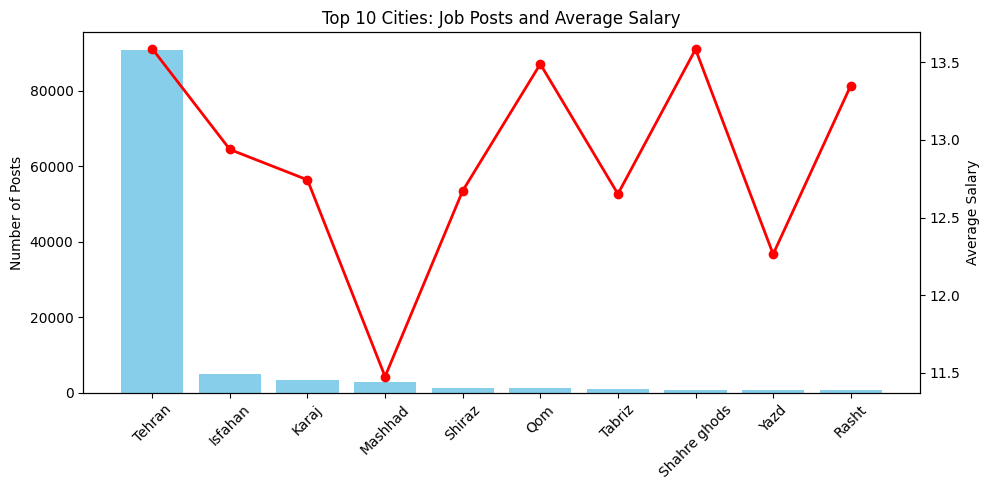

In [6]:
import matplotlib.pyplot as plt

top10 = city_stats.head(10)

fig, ax1 = plt.subplots(figsize=(10,5))


ax1.bar(top10.index, top10["Number_of_Posts"], color="skyblue", label="Number of Posts")
ax1.set_ylabel("Number of Posts")


ax2 = ax1.twinx()
ax2.plot(top10.index, top10["Average_Salary"],
         color="red", marker="o", linewidth=2,
         label="Average Salary")
ax2.set_ylabel("Average Salary")

ax1.tick_params(axis="x", rotation=45)

plt.title("Top 10 Cities: Job Posts and Average Salary")
plt.tight_layout()
plt.show()